# Step 0: EDA
Understanding the data is crucial in ML/DL.  
Image types, sizes, and class distribution impact performance.  
Class imbalance can bias the model.  
Careful analysis leads to better results.


In [1]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def get_random_images(dataset_path, num_images=9):
    """Get random images from the dataset folder."""
    all_folders = [os.path.join(dataset_path, str(i)) for i in range(100) if os.path.isdir(os.path.join(dataset_path, str(i)))]
    all_images = []

    # Collect images from each folder
    for folder in all_folders:
        images = [os.path.join(folder, img) for img in os.listdir(folder) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        all_images.extend(images)

    # Select random images
    return random.sample(all_images, min(num_images, len(all_images)))

def display_images(images):
    """Display images in a 3x3 grid."""
    fig, axes = plt.subplots(3, 3, figsize=(9, 9))
    for ax, img_path in zip(axes.ravel(), images):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(os.path.basename(img_path))
        ax.axis('off')

    plt.tight_layout()
    plt.show()

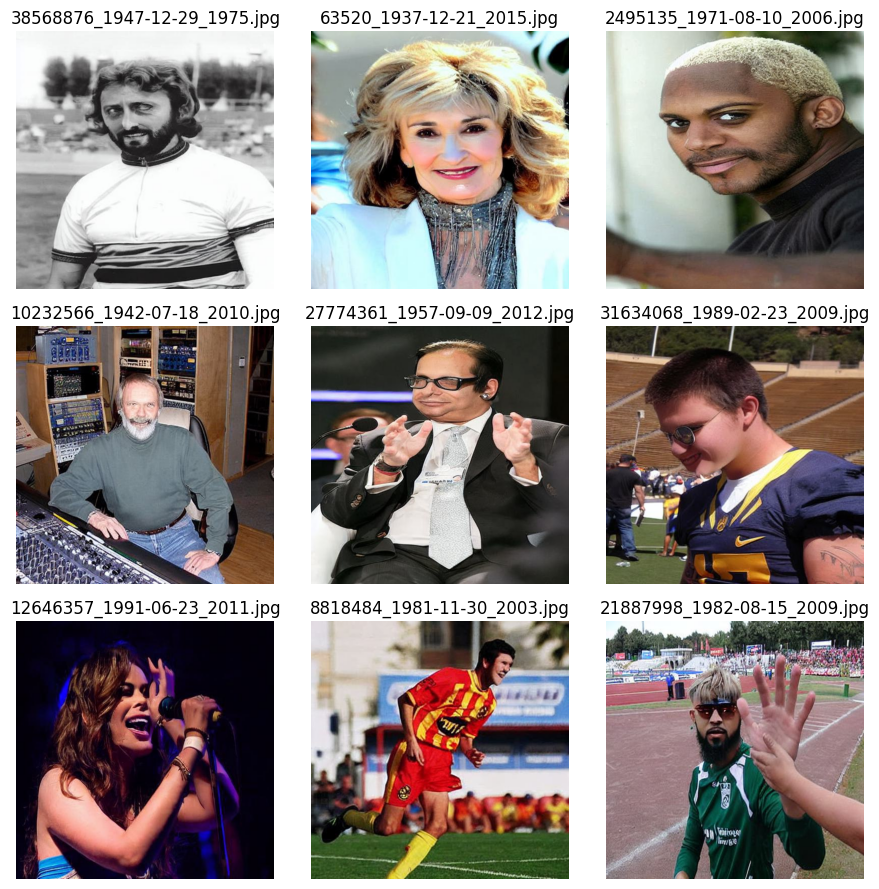

In [19]:
dataset_path = 'inpainting' # inpainting, insight, text2img, wiki

if not os.path.exists(dataset_path):
    print("Invalid path. Please enter a valid dataset folder path.")
else:
    images = get_random_images(dataset_path)
    if images:
        display_images(images)
    else:
        print("No images found in the dataset.")

In [17]:
def get_sampled_image_sizes(dataset_name, sample_size=50, max_unique_sizes=10):
    """Get unique image sizes from a random sample of images in a dataset folder."""
    all_images = []
    for root, _, files in os.walk(dataset_name):
        images = [os.path.join(root, f) for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        all_images.extend(images)

    sampled_images = random.sample(all_images, min(sample_size, len(all_images)))
    sizes = set()

    for img_path in sampled_images:
        img = cv2.imread(img_path)
        if img is not None:
            sizes.add(img.shape[:2])
            if len(sizes) > max_unique_sizes:
                return f"{dataset_name}: various sizes"

    if len(sizes) == 1:
        return f"{dataset_name}: unique size {next(iter(sizes))}"
    return f"{dataset_name}: various sizes"

def analyze_datasets(dataset_paths):
    """Analyze multiple datasets and print their image size distribution."""
    for dataset_name in dataset_paths:
        if os.path.exists(dataset_name):
            print(get_sampled_image_sizes(dataset_name))
        else:
            print(f"{dataset_name}: path not found")

# Example usage
dataset_paths = ['inpainting', 'insight', 'text2img', 'wiki']
analyze_datasets(dataset_paths)

inpainting: unique size (512, 512)
insight: unique size (512, 512)
text2img: unique size (512, 512)
wiki: various sizes


## Conclusions

Initially, after analyzing the *wiki* dataset (containing real images), we considered removing certain images that did not contain faces, such as motorcycles, large background scenes, and full-body shots. However, upon examining the other datasets (which contain synthetic images), we observed that they also included backgrounds and full-body representations. As a result, it was unnecessary to filter out such images from the real dataset.

The three synthetic datasets all have a uniform image size of **512×512**, whereas the real *wiki* dataset contains images of varying dimensions. To ensure consistency, we will likely need to either crop or resize the real images, depending on the preprocessing requirements of the chosen algorithms.

Each dataset contains **30,000 images**, but with only one real dataset and three synthetic ones, there is an imbalance in the data distribution. To maintain balance for a classification model, we may need to **downsample the synthetic datasets to 10,000 images each** or **oversample the real dataset**. However, augmentation strategies are limited, as only vertical flipping is a reasonable transformation—rotations of **90° or 180°** would distort human subjects. Even with vertical flips, we would only achieve **60,000 real images versus 90,000 synthetic ones**, leaving an imbalance.

Therefore, we must carefully determine how to **address both the class imbalance and the variation in image sizes** to ensure optimal model performance.